## Salary Prediction using Multiple Linear Regression

### Notebook 04: Feature Engineering & Model Building

---

### Objective

The objective of this notebook is to prepare the processed salary dataset for machine learning model training and develop a Multiple Linear Regression model capable of predicting employee salaries.

In this notebook, we will:

- Split the processed dataset into training and testing sets.
- Build a preprocessing pipeline for numerical and categorical features.
- Train a Multiple Linear Regression model.
- Evaluate the model using regression metrics.
- Analyze prediction residuals.
- Save the trained model and preprocessing pipeline for deployment.

---

### Problem Context

After completing data exploration, cleaning, and preprocessing in the previous notebooks, the dataset is now ready for machine learning.

The salary prediction problem is a supervised regression task because the target variable (**salary_in_usd**) is continuous.

To build a reliable predictive model, we must prepare the dataset correctly, train the regression model, and evaluate its performance using appropriate regression metrics.

The trained model developed in this notebook will later be used inside the Streamlit application to predict employee salaries based on user inputs.

> **Note:** This notebook focuses on feature engineering, model development, evaluation, and model persistence. Deployment will be handled separately through the Streamlit application.

### Step 1: Import Required Libraries

In this step, we import the libraries required for feature engineering, preprocessing, model training, evaluation, and model persistence.

These libraries provide the essential tools needed to build a complete machine learning pipeline.

In [1]:
import warnings

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load Processed Dataset

The processed salary dataset created during Notebook 03 is loaded for model building.

This dataset has already undergone feature selection and preprocessing preparation, making it suitable for machine learning.

In [2]:
df = pd.read_csv(r"D:\\machine learning\\machine_learning\\linear_regression_project\\salary_prediction\\data\\clean_data\\cleaned_salaries.csv")

print("Processed dataset loaded successfully.")

Processed dataset loaded successfully.


### Step 3: Dataset Inspection

Before training the model, we briefly inspect the processed dataset to verify its structure and ensure that it has been loaded correctly.

This includes:

- Dataset information
- Statistical summary
- Preview of the dataset

In [3]:
df.info()

display(df.describe(include="all").T)

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70159 entries, 0 to 70158
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           70159 non-null  int64 
 1   experience_level    70159 non-null  object
 2   employment_type     70159 non-null  object
 3   job_title           70159 non-null  object
 4   salary_in_usd       70159 non-null  int64 
 5   employee_residence  70159 non-null  object
 6   remote_ratio        70159 non-null  int64 
 7   company_location    70159 non-null  object
 8   company_size        70159 non-null  object
dtypes: int64(3), object(6)
memory usage: 4.8+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
work_year,70159.0,NaN,NaN,NaN,2024.422497,0.723618,2020.0,2024.0,2025.0,2025.0,2025.0
experience_level,70159,4,SE,36623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,70159,4,FT,69415,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,70159,419,Data Scientist,7048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_in_usd,70159.0,NaN,NaN,NaN,144696.468122,64832.364871,15000.0,95000.0,136700.0,185800.0,331640.0
employee_residence,70159,104,US,58421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
remote_ratio,70159.0,NaN,NaN,NaN,24.839294,43.074588,0.0,0.0,0.0,50.0,100.0
company_location,70159,97,US,58483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,70159,3,M,68375,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,232344,US,0,US,M
1,2025,SE,FT,Data Scientist,145400,US,0,US,M
2,2025,SE,FT,Data Scientist,81600,US,0,US,M
3,2025,MI,FT,Engineer,160000,US,100,US,M
4,2025,MI,FT,Engineer,140000,US,100,US,M


### Step 4: Data Splitting

Machine learning models should be evaluated on unseen data.

To achieve this, we divide the dataset into:

- Training Set (80%)
- Testing Set (20%)

The training set is used to learn the relationships within the data, while the testing set is used to evaluate the model's ability to generalize to new observations.

In [4]:
X = df.drop(columns=["salary_in_usd"])

y = df["salary_in_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (56127, 8)
Testing Features  : (14032, 8)
Training Labels   : (56127,)
Testing Labels    : (14032,)


### Step 5: Feature Engineering

Machine learning algorithms require numerical input.

Therefore, we apply different preprocessing techniques to numerical and categorical features.

#### Numerical Features

Numerical variables are standardized using **StandardScaler**.

#### Categorical Features

Categorical variables are transformed using **OneHotEncoder**.

A **ColumnTransformer** allows these preprocessing steps to be applied simultaneously within a unified pipeline.

In [5]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include="object"
).columns

numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Feature engineering pipeline created successfully.")

Feature engineering pipeline created successfully.


### Step 6: Model Building

A Multiple Linear Regression model is created using Scikit-learn's Pipeline.

The pipeline first preprocesses the input features and then trains the regression model.

Using a pipeline ensures that the same preprocessing steps are automatically applied during both training and prediction.

In [6]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_regression_model.fit(
    X_train,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


### Step 7: Model Evaluation

The trained model is evaluated using several regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Cross-Validation Score

These metrics provide insight into the model's prediction accuracy and generalization performance.

In [7]:
y_pred = linear_regression_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 42319.53
MSE  : 2821319293.02
RMSE : 53116.09
R²   : 0.3348


In [8]:
cv_scores = cross_val_score(
    linear_regression_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Average CV Score :", cv_scores.mean())

print("Standard Deviation :", cv_scores.std())

Average CV Score : 0.3218446896364225
Standard Deviation : 0.006077626216478432


### Step 8: Residual Analysis

Residual analysis helps evaluate the quality of the regression model by examining the differences between actual and predicted salaries.

Ideally, residuals should be randomly distributed around zero without any clear patterns.

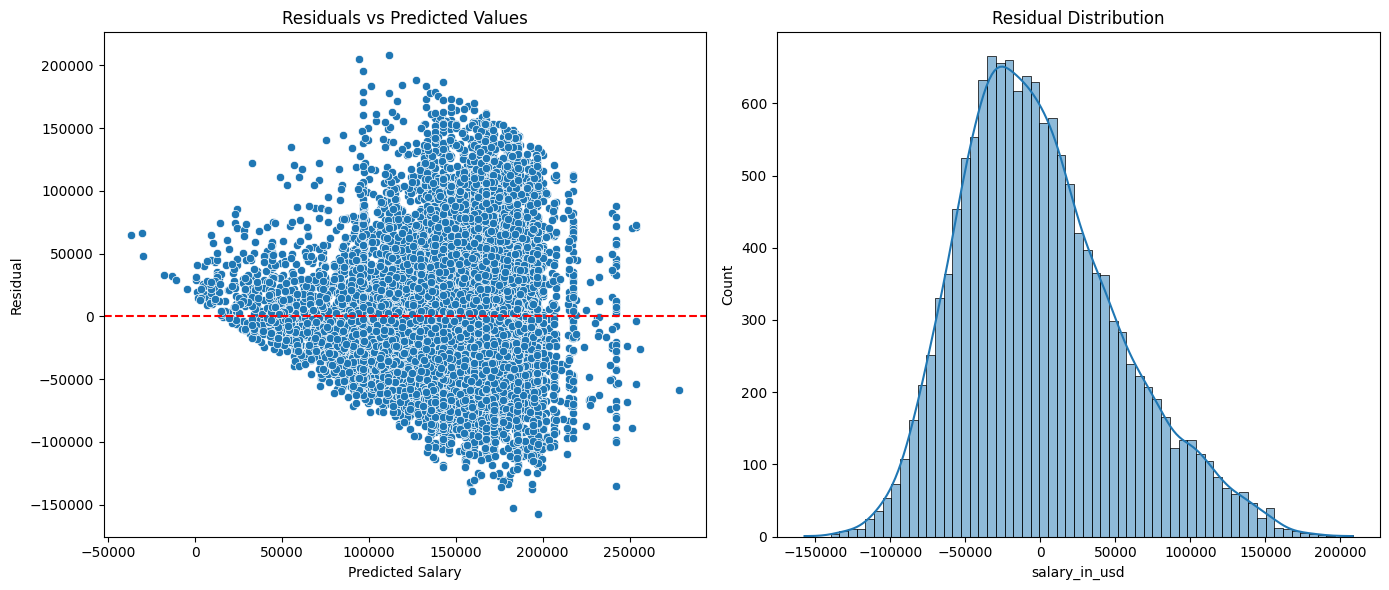

In [9]:
residuals = y_test - y_pred

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Salary")

plt.ylabel("Residual")

plt.title("Residuals vs Predicted Values")

plt.subplot(1,2,2)

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.tight_layout()

plt.show()

### Step 9: Save Model

To prepare for deployment, the trained machine learning pipeline is saved using Joblib.

Saving the pipeline ensures that both preprocessing and prediction steps remain consistent when the model is deployed in the Streamlit application.

In [10]:
joblib.dump(
    linear_regression_model,
    r"D:\machine learning\machine_learning\linear_regression_project\salary_prediction\model\linear_regression_model.joblib"
)

print("Model saved successfully.")

Model saved successfully.


## Final Conclusion

In this notebook, we successfully completed the machine learning phase of the Salary Prediction project.

We began by loading the processed dataset and splitting it into training and testing subsets to ensure an unbiased evaluation of the model.

A preprocessing pipeline was then constructed using StandardScaler for numerical features and OneHotEncoder for categorical features. These preprocessing steps were integrated with a Multiple Linear Regression model using Scikit-learn's Pipeline, ensuring a consistent workflow during both training and inference.

The trained model was evaluated using multiple regression metrics, including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), R² Score, and Cross-Validation. Residual analysis was also performed to assess prediction errors and verify the model's assumptions.

Finally, the complete machine learning pipeline was saved using Joblib, making it ready for deployment in the Streamlit application.

The project has now progressed from raw data exploration to a fully trained and deployable salary prediction model.